# Telco Customer Churn Prediction

**Dataset:** Telco Customer Churn (Kaggle)  
**Tools:** Python · Pandas · Scikit-learn · XGBoost · SHAP · Seaborn

---

## Project Goal

Predict whether a telecom customer will churn (leave the service) using supervised machine learning.  
The objective is not just accuracy — it is to **identify churners early** so the business can act before losing them.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Cleaning](#2-data-cleaning)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Training & Evaluation](#5-model-training--evaluation)
   - 5.1 Logistic Regression
   - 5.2 Random Forest
   - 5.3 XGBoost
   - 5.4 ROC & Precision-Recall Curves
   - 5.5 Threshold Optimisation
   - 5.6 Feature Importance
   - 5.7 SHAP Values (Explainability)
   - 5.8 Cross-Validation Stability
6. [Final Model Comparison](#6-final-model-comparison)
7. [Conclusion & Business Recommendations](#7-conclusion--business-recommendations)


## 1. Setup & Data Loading

We begin by importing all required libraries and loading the dataset.

The dataset contains 7,043 customer records and 21 columns, including customer demographics, account information, service details, charges, and the churn outcome.


In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Quick overview of data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

### 2.1 Handling Missing & Malformed Values

The `TotalCharges` column is stored as an object (string) instead of float.  
This happens because rows with 0 tenure contain a blank space `' '` instead of a number — likely new customers who haven't been billed yet.

We convert the column to numeric, which turns those blank spaces into `NaN`, then drop the 11 affected rows.


In [ ]:
df_clean = df.copy()

# Fix TotalCharges dtype — blank strings become NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

missing_before = df_clean['TotalCharges'].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_before}")


Missing values in TotalCharges after conversion: 11


In [ ]:
# Drop rows with missing values (only 11 out of 7,043 — safe to remove)
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)

print(f"Rows removed : {7043 - len(df_clean)}")
print(f"Final dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")


Rows removed : 11
Final dataset: 7032 rows × 21 columns
Duplicate rows: 0


### 2.2 Cleaning Summary

| Check | Result |
|---|---|
| Original rows | 7,043 |
| Missing values removed | 11 |
| Duplicate rows | 0 |
| **Final rows** | **7,032** |

The dataset is clean and ready for analysis.


## 3. Exploratory Data Analysis

### 3.1 Target Variable — Churn Distribution

Before building any model, we need to understand the class distribution of the target variable `Churn`.


In [ ]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts.to_string())
print()
print("Churn Percentages:")
print(churn_pct.round(1).to_string())


Churn Counts:
Churn
No     5163
Yes    1869

Churn Percentages:
Churn
No     73.4
Yes    26.6


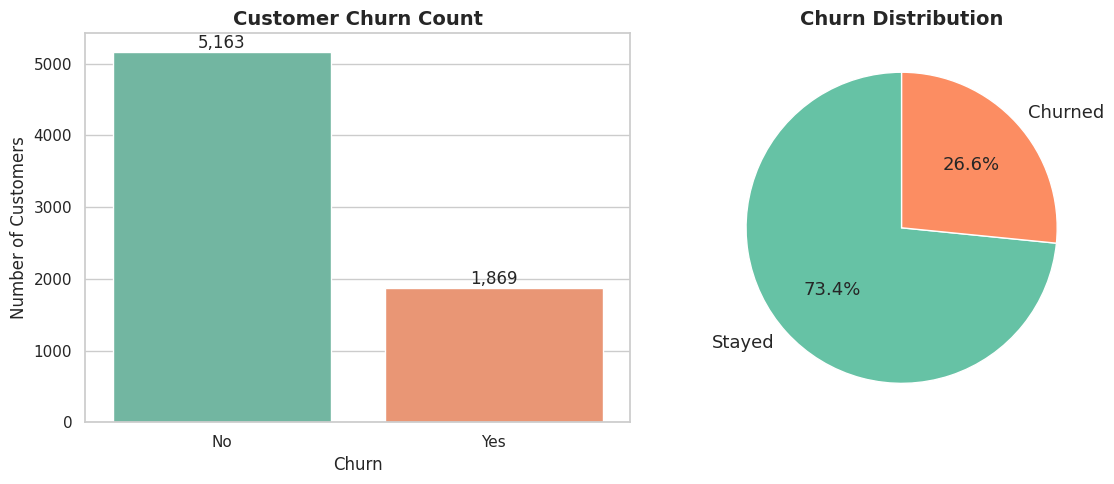

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df_clean, x='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Churn Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


**Insight:** The dataset is **moderately imbalanced** — 73.4% stayed vs 26.6% churned.  
Roughly 1 in 4 customers left, which represents significant revenue leakage for any telecom business.

> ⚠️ Because of this imbalance, **accuracy alone is misleading**. We will prioritise **Recall** and **F1-score** to measure how well models detect actual churners.


### 3.2 Contract Type vs Churn

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


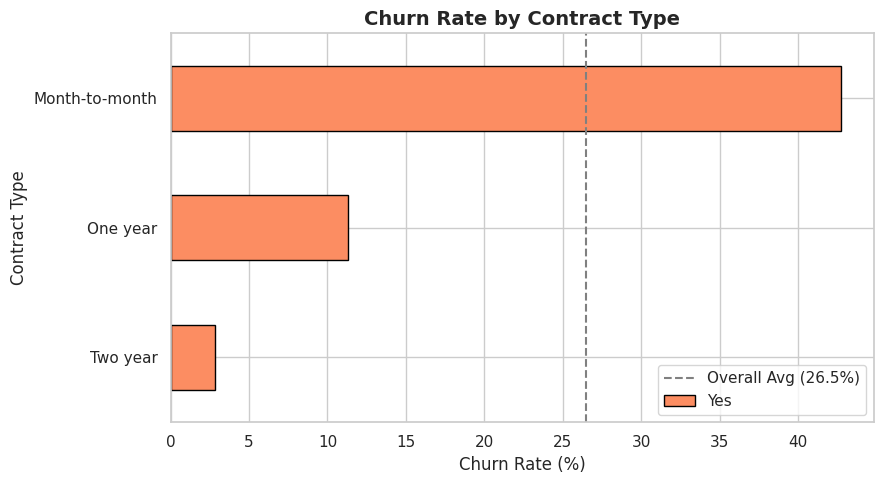

In [ ]:
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(contract_churn.round(1))

plt.figure(figsize=(9, 5))
contract_churn['Yes'].sort_values().plot(kind='barh', color=sns.color_palette('Set2')[1], edgecolor='black')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Contract Type')
plt.axvline(26.5, color='grey', linestyle='--', label='Overall Avg (26.5%)')
plt.legend()
plt.tight_layout()
plt.show()


| Contract Type | Churn Rate |
|---|---|
| Month-to-month | **42.7%** |
| One year | 11.3% |
| Two year | 2.8% |

**Key Insight:** Month-to-month customers are 15× more likely to churn than two-year contract holders.  
This is one of the **strongest predictors** in the dataset — contract type creates commitment, switching friction, and deeper customer relationships.


### 3.3 Tenure vs Churn

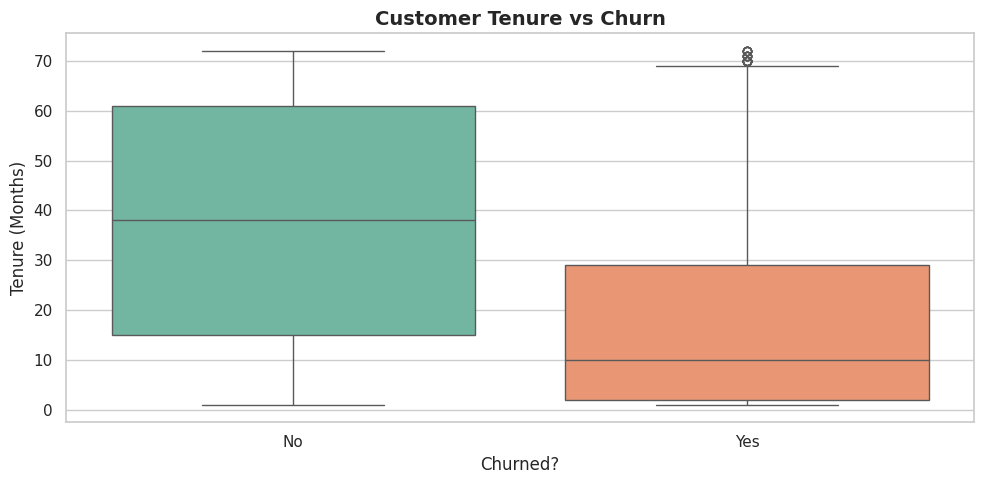

Churn
No     38.0
Yes    10.0
Name: Median Tenure (months), dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Churn', y='tenure', palette='Set2')
plt.title('Customer Tenure vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churned?')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

# Print median tenure per group
print(df_clean.groupby('Churn')['tenure'].median().rename("Median Tenure (months)"))


**Insight:** Churned customers have a median tenure of ~10 months vs ~38 months for those who stayed.  
The **first year is the danger zone** — customers who survive past 12 months become significantly more loyal.

> 📌 Business action: Focus onboarding quality and early-stage retention offers in months 1–12.


### 3.4 Monthly Charges vs Churn

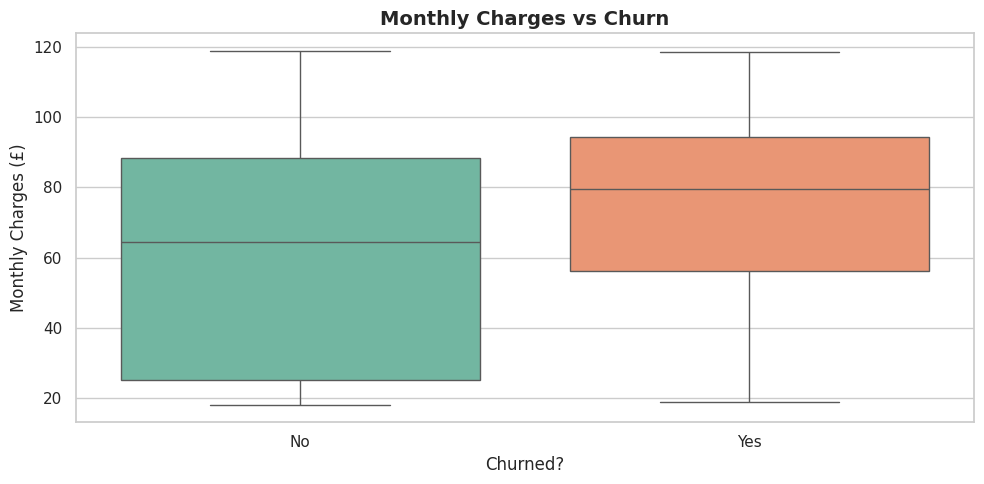

Churn
No     64.45
Yes    79.65
Name: Median Monthly Charges (£), dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges (£)')
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['MonthlyCharges'].median().rename("Median Monthly Charges (£)"))


**Insight:** Churned customers pay a higher median monthly charge (**£79.65 vs £64.45** for those who stayed).  
A ~£15/month difference suggests price sensitivity is a real churn driver — customers may be leaving for cheaper competitors or perceiving poor value for money.

> 📌 Business action: Flag customers paying above £75/month for proactive value-add outreach.


### 3.5 Correlation Heatmap (Numeric Features)

A quick look at how numeric features correlate with each other and with churn.


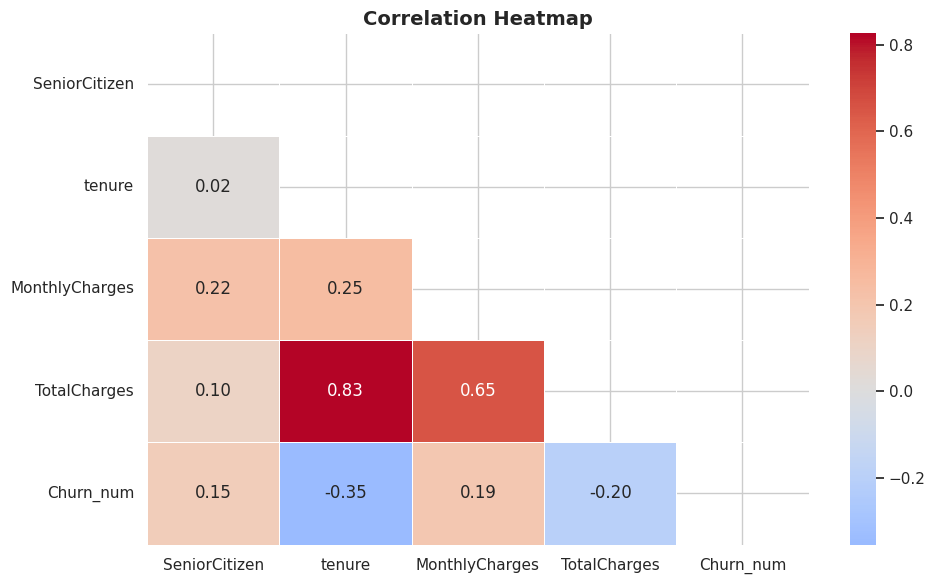

In [ ]:
# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Map Churn to numeric for correlation
df_corr = df_clean.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})
df_corr = df_corr[numeric_cols + ['Churn_num']]

plt.figure(figsize=(10, 6))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight:** `tenure` shows a moderate **negative correlation** with churn (**-0.35**), indicating that longer-tenured customers are less likely to leave.  

`MonthlyCharges` and `TotalCharges` are strongly correlated, while `tenure` and `TotalCharges` are highly correlated due to cumulative billing over time. This suggests potential multicollinearity to monitor in linear models.  

`SeniorCitizen` shows a small positive relationship with churn.

## 4. Feature Engineering

We prepare the dataset for modelling:
- **Encode target:** `Churn` mapped to 0 (Stayed) / 1 (Churned)
- **Drop identifier:** `customerID` is not a predictive feature
- **One-hot encode** all categorical columns using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity

After encoding, the dataset expands from **21 columns to 31** (30 features + 1 target).


In [ ]:
df_model = df_clean.copy()

# Encode target variable
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

# Drop non-predictive ID column
df_model = df_model.drop('customerID', axis=1)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_model, drop_first=True)

print(f"Encoded dataset shape: {df_encoded.shape}")
df_encoded.head(3)


Encoded dataset shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratified split to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test : {y_test.mean()*100:.1f}%")


Training set : 5,625 rows
Test set     : 1,407 rows
Churn rate in train: 26.6%
Churn rate in test : 26.6%


## 5. Model Training & Evaluation

We train three models and use **GridSearchCV with 5-fold cross-validation** to tune each one.  
Primary metric: **F1-score** — balances precision and recall, appropriate for imbalanced churn data.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

def evaluate_model(name, y_true, y_pred):
    """Print evaluation metrics and plot confusion matrix."""
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred)*100:.1f}%")
    print(f"  Precision: {precision_score(y_true, y_pred)*100:.1f}%")
    print(f"  Recall   : {recall_score(y_true, y_pred)*100:.1f}%")
    print(f"  F1 Score : {f1_score(y_true, y_pred)*100:.1f}%")
    print()
    print(classification_report(y_true, y_pred, target_names=['Stayed', 'Churned']))

    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Stayed', 'Churned'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 5.1 Logistic Regression

Logistic Regression is our **baseline model** — interpretable, fast, and well-suited for binary classification.  
We add a `StandardScaler` inside a Pipeline since LR is sensitive to feature scale, and tune via GridSearchCV.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, random_state=42))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print(f"Best CV F1 Score: {grid_lr.best_score_*100:.1f}%")


Best Parameters: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__solver': 'liblinear'}
Best CV F1 Score: 63.3%


  Tuned Logistic Regression
  Accuracy : 72.6%
  Precision: 49.1%
  Recall   : 79.7%
  F1 Score : 60.8%

              precision    recall  f1-score   support

      Stayed       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



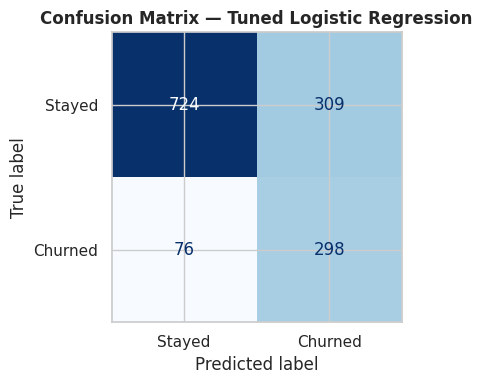

In [ ]:
best_lr = grid_lr.best_estimator_
lr_pred = best_lr.predict(X_test)

evaluate_model("Tuned Logistic Regression", y_test, lr_pred)


**Results — Logistic Regression (Tuned):**

| Metric | Score |
|---|---|
| Accuracy | 72.6% |
| Precision | 49.1% |
| Recall | **79.7%** |
| F1 Score | 60.8% |
| Best CV F1 (5-fold) | 63.3% |

**Best hyperparameters found:** `C=1`, `solver=liblinear`, `class_weight=balanced`

The tuned Logistic Regression model achieved strong recall (**79.7%**), meaning it identified a large proportion of actual churners. The selected `class_weight='balanced'` setting helps the model give more importance to the minority churn class, which is useful for imbalanced churn prediction.

> From a business standpoint, missing a churner is usually more costly than a false alarm. A retention call or offer is less expensive than losing a customer entirely, so prioritising recall is appropriate for this use case.

### 5.2 Random Forest

Random Forest is an ensemble model that builds many decision trees and aggregates their votes.  
It handles non-linearity and feature interactions well, and is robust to outliers.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print(f"Best CV F1 Score: {rf_grid.best_score_*100:.1f}%")


Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 Score: 64.0%


  Tuned Random Forest
  Accuracy : 74.8%
  Precision: 51.7%
  Recall   : 78.3%
  F1 Score : 62.3%

              precision    recall  f1-score   support

      Stayed       0.90      0.73      0.81      1033
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



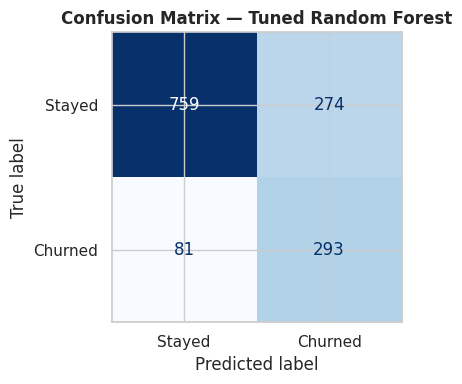

In [ ]:
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, rf_pred)


**Results — Random Forest (Tuned):**

| Metric | Score |
|---|---|
| Accuracy | 74.8% |
| Precision | 51.7% |
| Recall | **78.3%** |
| F1 Score | **62.3%** |
| Best CV F1 (5-fold) | 64.0% |

**Best hyperparameters found:** `n_estimators=300`, `max_depth=8`, `min_samples_split=5`, `min_samples_leaf=4`, `max_features=sqrt`

The tuned Random Forest achieved a strong **CV F1 score of 64.0%** and test-set recall of **78.3%**, meaning it correctly identified over 3 in 4 customers who would churn.

Compared with the tuned Logistic Regression model, Random Forest delivered a higher **F1 Score (62.3% vs 60.8%)** while maintaining similar recall. Its ensemble structure also makes it effective at capturing non-linear patterns and feature interactions.

### 5.3 XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially, with each tree correcting the errors of the previous one.  
It is often the strongest performer in structured/tabular ML competitions.


In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print(f"Best CV F1 Score: {xgb_grid.best_score_*100:.1f}%")


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1 Score: 59.3%


**Best hyperparameters found:** `n_estimators=100`, `max_depth=3`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`

The tuned XGBoost model achieved a **5-fold CV F1 score of 59.3%**.  
While XGBoost is often highly effective on tabular datasets, this result suggests that simpler models or bagging-based ensembles performed better for this churn problem.

  Tuned XGBoost
  Accuracy : 79.3%
  Precision: 63.3%
  Recall   : 52.9%
  F1 Score : 57.6%

              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1033
     Churned       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



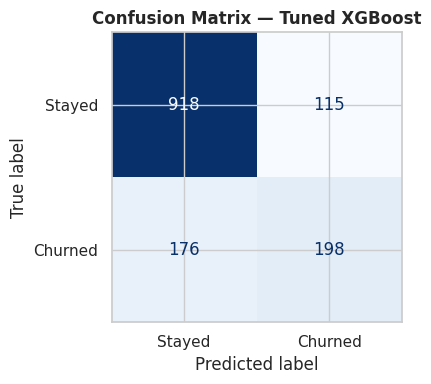

In [ ]:
best_xgb = xgb_grid.best_estimator_
xgb_pred = best_xgb.predict(X_test)

evaluate_model("Tuned XGBoost", y_test, xgb_pred)


**Results — XGBoost (Tuned):**

| Metric | Score |
|---|---|
| Accuracy | **79.3%** |
| Precision | **63.3%** |
| Recall | 52.9% |
| F1 Score | 57.6% |
| Best CV F1 (5-fold) | 59.3% |

**Best hyperparameters found:** `n_estimators=100`, `max_depth=3`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`

Among the tuned models evaluated, XGBoost achieved the **highest accuracy (79.3%) and precision (63.3%)**. This means that when it predicts churn, it is more often correct. However, its **recall of 52.9% was the lowest**, meaning it missed many actual churners.

This trade-off makes XGBoost more suitable for scenarios where **retention resources are limited and false positives are costly**, such as targeted outreach to selected high-value customers.

> ⚠️ Despite XGBoost’s strong reputation, it did not outperform Random Forest on F1-score in this project. This highlights that model performance depends heavily on the dataset and feature engineering, not just algorithm complexity.

## 5.4 ROC & Precision-Recall Curves

ROC-AUC and Precision-Recall curves give a fuller picture of model performance across all classification thresholds — not just the default 0.5 cutoff.

- **ROC-AUC** closer to 1.0 = better discrimination between churners and non-churners  
- **PR-AUC** is more informative for imbalanced datasets — it directly shows the precision/recall trade-off


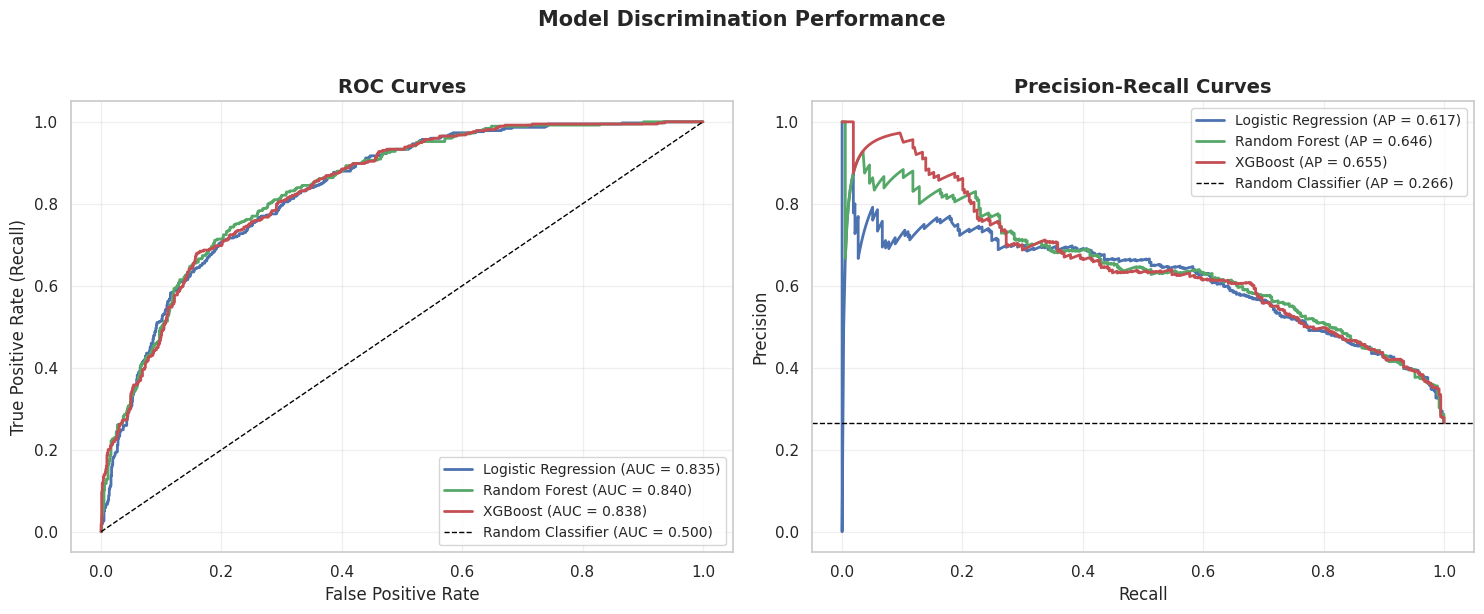


ROC-AUC & Average Precision Summary:
Model                        ROC-AUC   Avg Precision
----------------------------------------------------
Logistic Regression            0.835           0.617
Random Forest                  0.840           0.646
XGBoost                        0.838           0.655


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get probability scores for each model
lr_proba  = best_lr.predict_proba(X_test)[:, 1]
rf_proba  = best_rf.predict_proba(X_test)[:, 1]
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

models_proba = {
    'Logistic Regression': lr_proba,
    'Random Forest':       rf_proba,
    'XGBoost':             xgb_proba
}

colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC Curves ──────────────────────────────────────────────
ax = axes[0]
for (name, proba), color in zip(models_proba.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# ── Precision-Recall Curves ──────────────────────────────────
ax = axes[1]
baseline_pr = y_test.mean()
for (name, proba), color in zip(models_proba.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(recall, precision, label=f'{name} (AP = {pr_auc:.3f})', color=color, lw=2)

ax.axhline(baseline_pr, color='k', linestyle='--', lw=1,
           label=f'Random Classifier (AP = {baseline_pr:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('Model Discrimination Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print AUC summary
print("\nROC-AUC & Average Precision Summary:")
print(f"{'Model':<25} {'ROC-AUC':>10} {'Avg Precision':>15}")
print("-" * 52)
for (name, proba) in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_test, proba)
    print(f"{name:<25} {roc_auc:>10.3f} {ap:>15.3f}")


### Model Discrimination Performance (ROC-AUC & Precision-Recall)

To assess ranking ability beyond standard classification metrics, ROC-AUC and Average Precision (area under the Precision-Recall curve) were compared across all three models.

| Model | ROC-AUC | Average Precision |
|---|---|---|
| Logistic Regression | 0.835 | 0.617 |
| **Random Forest** | **0.840** | 0.646 |
| XGBoost | 0.838 | **0.655** |

**ROC-AUC** measures how well a model separates churners from non-churners across all probability thresholds:

- All three models scored in the **0.835–0.840 range**, well above the 0.5 random baseline, indicating strong discriminative ability.
- Random Forest achieved the highest ROC-AUC (0.840), although the gap between models is very small.

**Average Precision (PR-AUC)** is more informative for imbalanced datasets because it focuses on the minority churn class:

- XGBoost achieved the highest Average Precision (0.655), suggesting slightly stronger ranking performance for identifying churners.
- Random Forest followed closely at 0.646.

> These results confirm that all three models are genuinely useful classifiers. The key differences lie in their ranking behaviour and classification trade-offs rather than whether they work.

### 5.5 Threshold Optimisation

By default, classifiers use a 0.5 probability threshold. But in churn problems, **the cost of missing a churner is higher than a false alarm** (retention outreach is cheap; losing a customer is expensive).

We can find the optimal threshold that maximises F1-score, or tune it to favour recall.


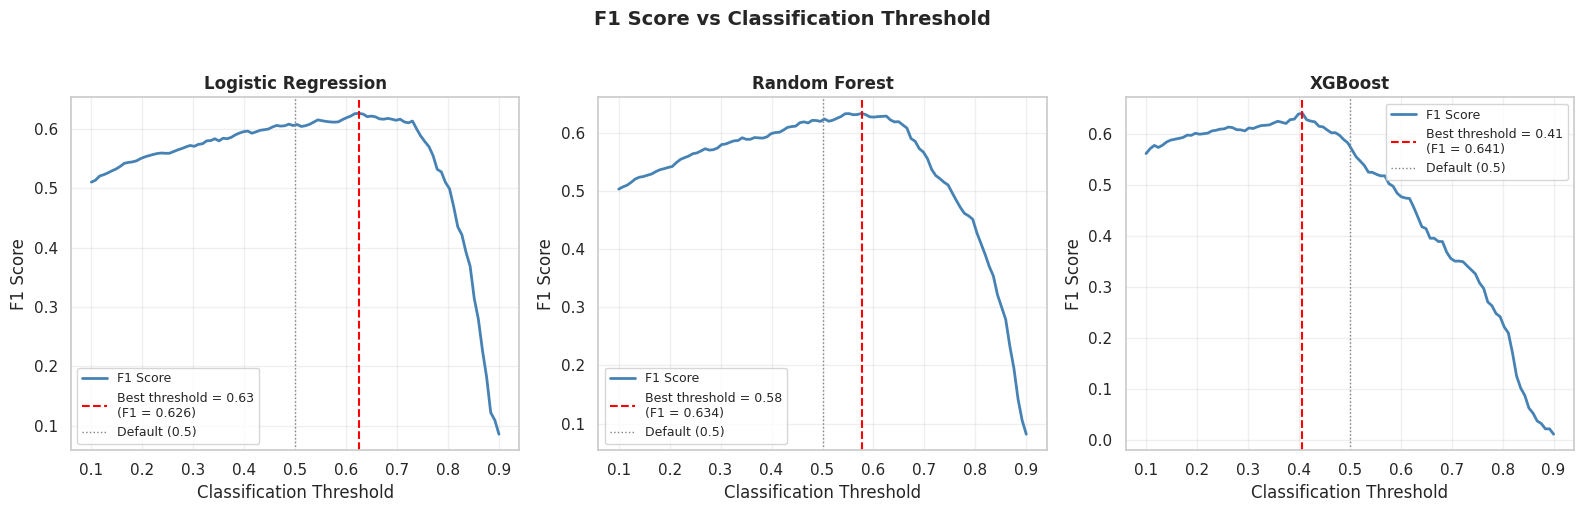

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, proba) in zip(axes, models_proba.items()):
    thresholds = np.linspace(0.1, 0.9, 100)
    f1_scores  = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in thresholds]
    recalls    = [f1_score(y_test, (proba >= t).astype(int), zero_division=0, average=None)[1] for t in thresholds]

    best_t  = thresholds[np.argmax(f1_scores)]
    best_f1 = max(f1_scores)

    ax.plot(thresholds, f1_scores, label='F1 Score', color='steelblue', lw=2)
    ax.axvline(best_t, color='red', linestyle='--', lw=1.5,
               label=f'Best threshold = {best_t:.2f}\n(F1 = {best_f1:.3f})')
    ax.axvline(0.5, color='grey', linestyle=':', lw=1, label='Default (0.5)')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Classification Threshold')
    ax.set_ylabel('F1 Score')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('F1 Score vs Classification Threshold', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Threshold Optimisation Analysis

Most classification models use a default probability threshold of **0.50**, where customers with a predicted churn probability above 50% are classified as churners. However, this default is not always optimal for business objectives.

The charts above show F1 Score evaluated across probability cut-offs from **0.10 to 0.90** for each model. The red dashed line marks the threshold that maximises F1, while the grey dotted line marks the default **0.50** threshold.

**Key observations:**

- **Logistic Regression** and **Random Forest** peak at thresholds slightly above 0.50, suggesting better balance when requiring slightly higher confidence before predicting churn.
- **XGBoost** peaks at a lower threshold (**~0.41**), meaning a reduced cut-off helps capture more churners, consistent with its lower recall at the default threshold.
- After threshold tuning, **XGBoost achieved the highest F1 score (0.641)** among the three models.

**Business guidance for threshold selection:**

| Objective | Recommended threshold |
|---|---|
| Maximise churn detection | Lower threshold (~0.3–0.4) to increase recall |
| Minimise wasted retention spend | Higher threshold (~0.6–0.7) to improve precision |
| Balanced performance | Use the model-specific F1-optimal threshold |

> In production, thresholds should be chosen using the **cost trade-off** between missed churners and unnecessary retention actions. This is ultimately a business decision, not just a modelling decision.

### Feature Importance Insights

The chart above shows the top 20 features by importance score from the tuned Random Forest (top 5 highlighted in red).

**Dominant features:**
- **`tenure`** — the single strongest predictor: customers who have been with the company longer are far less likely to churn
- **`MonthlyCharges`** and **`TotalCharges`** — higher billing correlates with higher churn risk, consistent with EDA findings
- **`Contract_Two year`** — being on a two-year contract strongly reduces churn probability
- **`InternetService_Fiber optic`** — fibre optic customers show elevated churn risk, possibly linked to higher costs or service quality expectations

> ⚠️ Random Forest feature importance can overweight high-cardinality and continuous numeric features (like `TotalCharges` and `MonthlyCharges`). The SHAP section below provides a more reliable and granular attribution for individual predictions.


## 5.6 SHAP Values: Model Explainability

**SHAP (SHapley Additive exPlanations)** is a widely used technique for interpreting machine learning models.

Unlike global feature importance, SHAP can explain **individual predictions**, showing how each feature increased or decreased a specific customer's predicted churn risk.

This adds an important layer of transparency to ML projects. In many business settings, explainability helps stakeholders trust model outputs and supports better decision-making.

In [ ]:
!pip install shap -q
import shap
shap.initjs()


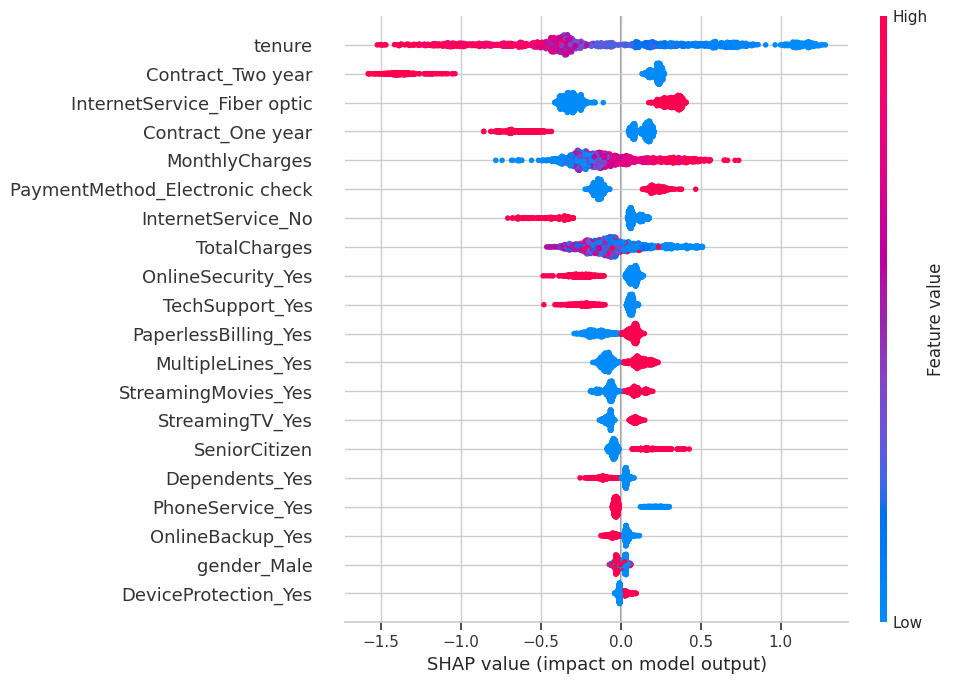

<Figure size 640x480 with 0 Axes>

In [ ]:
# Compute SHAP values for XGBoost (fastest with TreeExplainer)
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# ── Summary Plot (Beeswarm) ──────────────────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='dot', max_display=20,
                  show=True, plot_size=(10, 7))
plt.suptitle('SHAP Summary Plot — XGBoost', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()


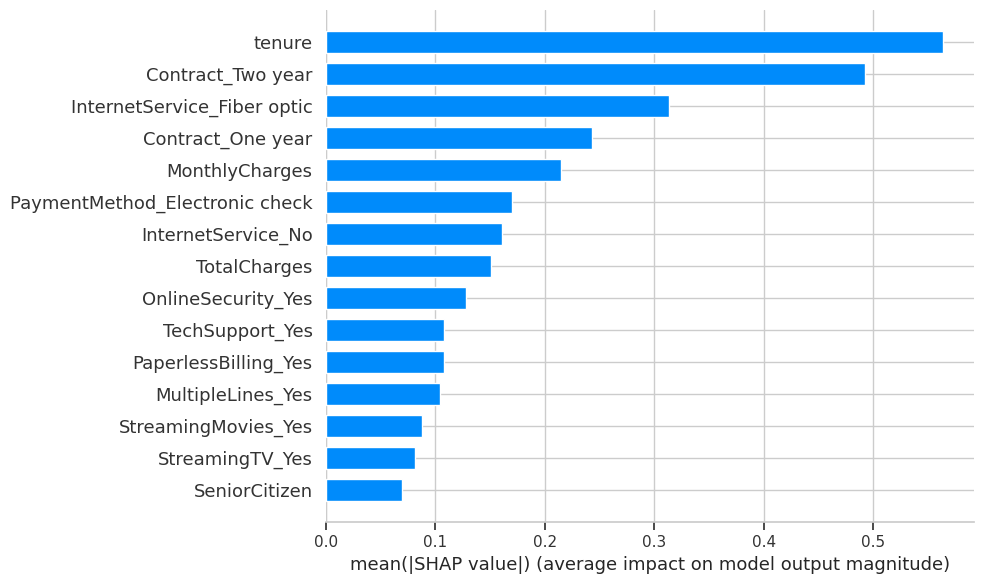

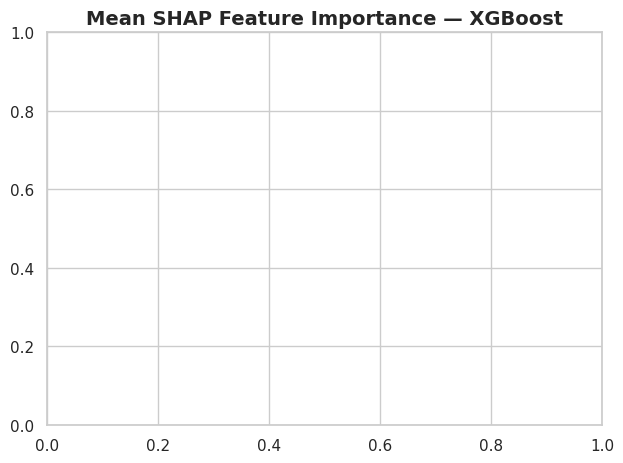

In [ ]:
# ── SHAP Bar Plot (mean absolute impact) ────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15,
                  show=True, plot_size=(10, 6))
plt.title('Mean SHAP Feature Importance — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()


Explaining prediction for customer index 1149
Predicted churn probability: 91.3%
Actual label: Churned


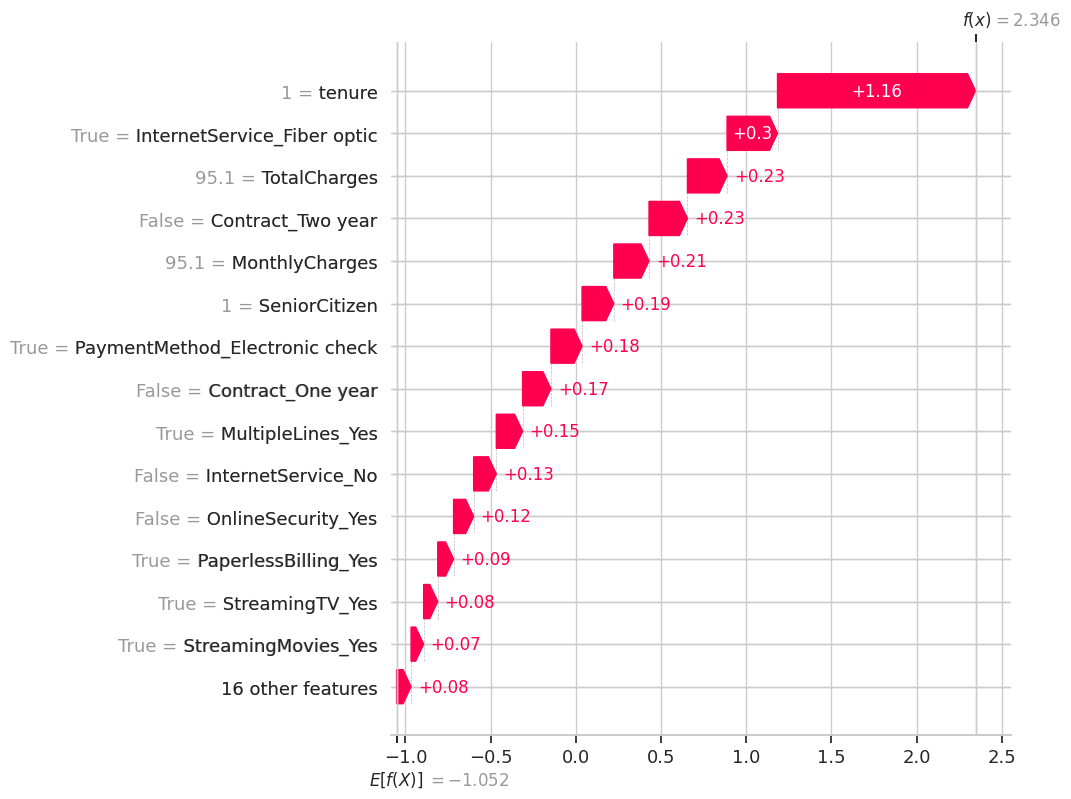

In [ ]:
# ── Waterfall Plot — single customer explanation ─────────────────────────
# Find a customer predicted to churn with high confidence
churn_proba = best_xgb.predict_proba(X_test)[:, 1]
high_risk_idx = churn_proba.argmax()

print(f"Explaining prediction for customer index {high_risk_idx}")
print(f"Predicted churn probability: {churn_proba[high_risk_idx]:.1%}")
print(f"Actual label: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Stayed'}")

shap_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(shap_explanation, max_display=15, show=True)


### How to Read the SHAP Plots

**Beeswarm Summary Plot:**
- Each dot represents one customer in the test set.
- **Red** indicates a high feature value, while **blue** indicates a low feature value.
- The x-axis shows whether a feature pushed the model output toward churn risk or away from churn risk.
- Features are ranked by their average absolute SHAP impact, with the most influential features at the top.

**SHAP Bar Plot:**
- Shows the average absolute SHAP impact for each feature, giving a cleaner global ranking of the most influential churn drivers.

**Waterfall Plot:**
- Explains the prediction for **Customer #1149**, the highest-risk customer in the test set.
- Predicted churn probability: **91.3%**.
- Each bar shows how much a specific feature increased or decreased the model output compared with the baseline expected value.

**Key findings from SHAP:**
- **Low `tenure`** is the strongest churn risk signal, confirming that newer customers are more vulnerable.
- **Not being on a two-year contract** increases churn risk, while longer contracts reduce churn risk.
- **`InternetService_Fiber optic = True`** increases churn risk, possibly linked to higher cost or perceived value issues.
- **Higher `MonthlyCharges`** also pushes churn risk upward, reinforcing the earlier EDA finding that churned customers pay higher monthly charges.
- **Electronic check payment method** appears as another churn-risk contributor.

> The waterfall plot is a useful retention-team output because it explains why a specific customer was flagged as high risk, making the model more transparent and actionable.

## 5.7 Cross-Validation Stability

A strong model should perform **consistently** across different data splits, rather than relying on one favourable test set.

To validate robustness, additional cross-validation can be run on the selected final model.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
for name, model in [('Logistic Regression', best_lr),
                     ('Random Forest',       best_rf),
                     ('XGBoost',             best_xgb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  F1 per fold : {[f'{s:.3f}' for s in scores]}")
    print(f"  Mean ± Std  : {scores.mean():.3f} ± {scores.std():.3f}\n")


Logistic Regression
  F1 per fold : ['0.645', '0.638', '0.632', '0.633', '0.613', '0.630', '0.631', '0.631', '0.614', '0.606']
  Mean ± Std  : 0.627 ± 0.012

Random Forest
  F1 per fold : ['0.633', '0.628', '0.626', '0.634', '0.633', '0.638', '0.633', '0.659', '0.638', '0.605']
  Mean ± Std  : 0.633 ± 0.013

XGBoost
  F1 per fold : ['0.590', '0.633', '0.586', '0.594', '0.587', '0.580', '0.572', '0.580', '0.595', '0.599']
  Mean ± Std  : 0.592 ± 0.016



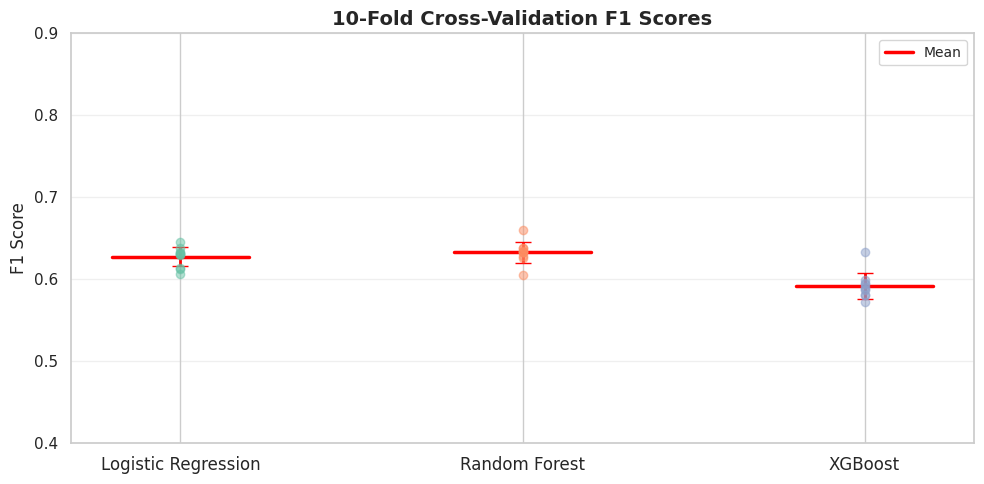

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = range(len(cv_results))
for i, (name, scores) in enumerate(cv_results.items()):
    ax.scatter([i]*len(scores), scores, alpha=0.5, zorder=3)
    ax.plot([i-0.2, i+0.2], [scores.mean(), scores.mean()],
            'r-', lw=2.5, label='Mean' if i == 0 else '')
    ax.errorbar(i, scores.mean(), yerr=scores.std(),
                fmt='none', color='red', capsize=6, lw=2)

ax.set_xticks(list(positions))
ax.set_xticklabels(list(cv_results.keys()), fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('10-Fold Cross-Validation F1 Scores', fontsize=14, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Cross-Validation Results Summary

| Model | Mean F1 (10-fold) | Std Dev |
|---|---|---|
| Logistic Regression | 0.627 | ±0.012 |
| **Random Forest** | **0.633** | ±0.013 |
| XGBoost | 0.592 | ±0.016 |

**Insight:** All three models show **low standard deviation** across folds, indicating stable performance rather than reliance on one favourable train/test split.

- **Random Forest** achieved the highest mean CV F1 (0.633) with consistent fold-to-fold performance.
- **Logistic Regression** was close behind (0.627) and similarly stable, which is a strong result for a simpler linear model.
- **XGBoost** recorded the lowest CV F1 (0.592) and the highest variance (±0.016), suggesting greater sensitivity to fold composition.

> Cross-validation provides strong evidence of model reliability because performance is tested repeatedly across multiple data splits rather than a single holdout set.

## 6. Final Model Comparison

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    'Model': [
        'Logistic Regression (Baseline)',
        'Logistic Regression (Tuned)',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)'
    ],
    'Accuracy': [80.2, 72.6, 76.4, 74.8, 79.3],
    'Precision': [64.5, 49.1, 54.0, 51.7, 63.3],
    'Recall': [57.2, 79.7, 75.1, 78.3, 52.9],
    'F1 Score': [60.6, 60.8, 62.9, 62.3, 57.6]
}

df_results = pd.DataFrame(results).set_index('Model')
df_results = df_results.sort_values('F1 Score', ascending=False)
df_results


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest (Baseline),76.4,54.0,75.1,62.9
Random Forest (Tuned),74.8,51.7,78.3,62.3
Logistic Regression (Tuned),72.6,49.1,79.7,60.8
Logistic Regression (Baseline),80.2,64.5,57.2,60.6
XGBoost (Tuned),79.3,63.3,52.9,57.6


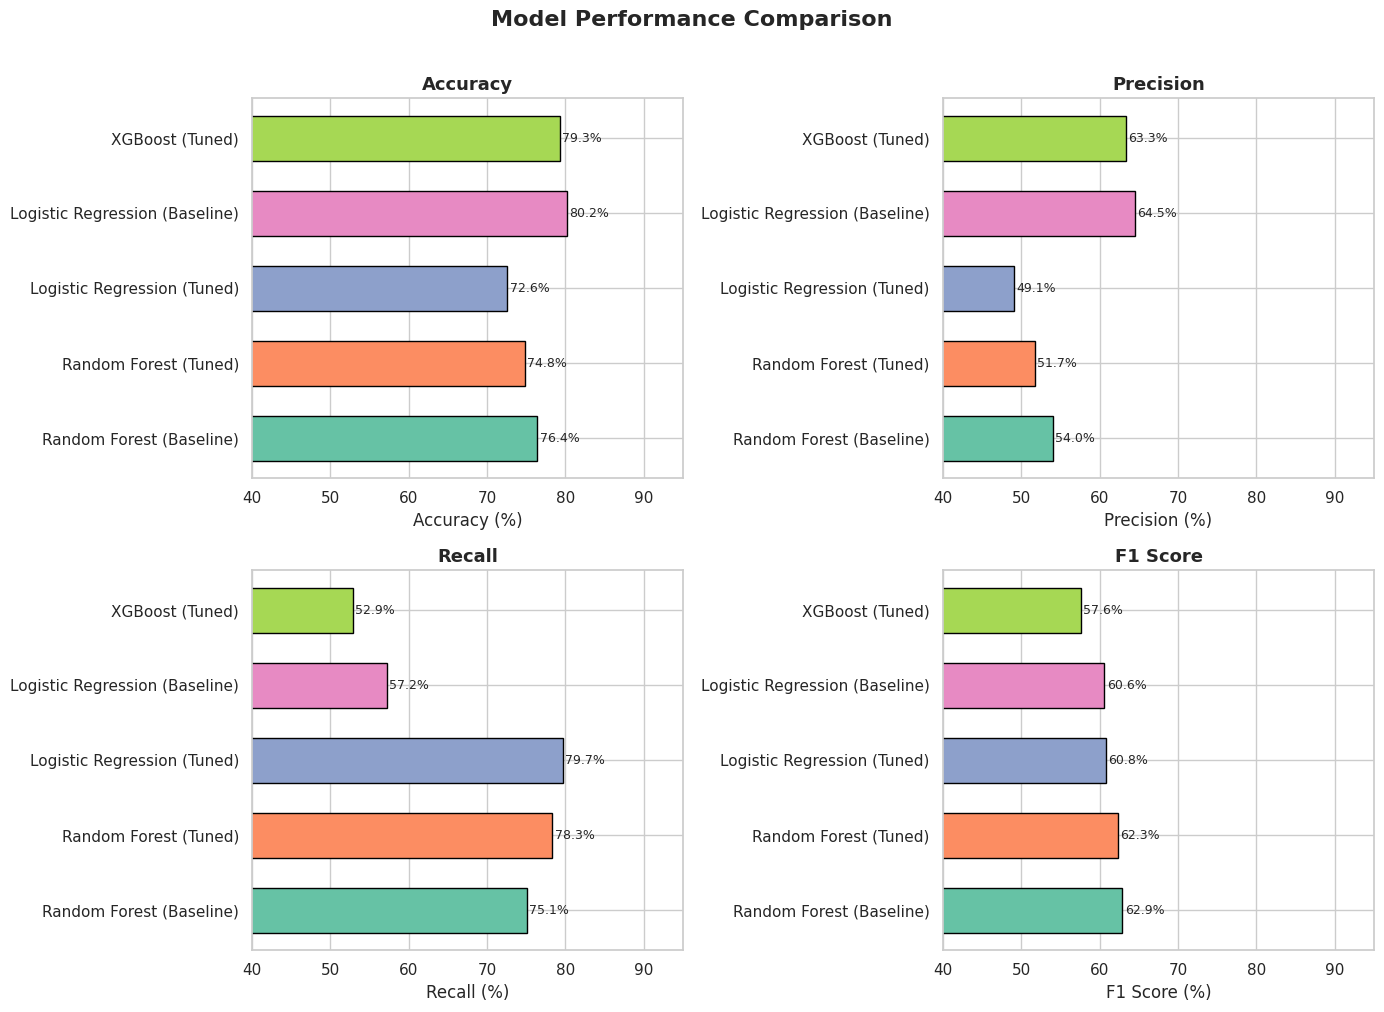

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = sns.color_palette('Set2', len(df_results))

for ax, metric in zip(axes.flat, metrics):
    bars = ax.barh(df_results.index, df_results[metric], color=colors, edgecolor='black', height=0.6)
    ax.set_xlabel(f'{metric} (%)')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim(40, 95)
    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


###  Final Model Leaderboard

| Rank | Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| 1 | Random Forest (Baseline) | 76.4% | 54.0% | 75.1% | **62.9%** |
| 2 | Random Forest (Tuned) | 74.8% | 51.7% | 78.3% | 62.3% |
| 3 | Logistic Regression (Tuned) | 72.6% | 49.1% | **79.7%** | 60.8% |
| 4 | Logistic Regression (Baseline) | **80.2%** | **64.5%** | 57.2% | 60.6% |
| 5 | XGBoost (Tuned) | 79.3% | 63.3% | 52.9% | 57.6% |

**Winner: Random Forest (Baseline)** achieved the highest test-set F1 score (**62.9%**), representing the strongest overall balance between detecting churners and limiting false alarms.

**Notable observations:**

- **Logistic Regression (Baseline)** achieved the highest raw accuracy (**80.2%**) and precision (**64.5%**), but lower recall.
- **XGBoost** also delivered high accuracy and precision, but the **lowest F1 and recall**, showing why accuracy alone can be misleading in imbalanced churn problems.
- **Logistic Regression (Tuned)** achieved the **highest recall (79.7%)**. If maximising churn capture is the primary objective, this is a strong deployment choice.
- Rebalancing techniques such as `class_weight='balanced'` improved recall for Logistic Regression and Random Forest, with an expected trade-off in precision.
- **Random Forest** achieved the best mean cross-validation F1 (**0.633 ± 0.013**), supporting it as the most balanced overall model.

## 7. Conclusion & Business Recommendations

### What the Model Tells Us

The strongest overall model (**Random Forest**) delivered the best balance of precision and recall, correctly identifying **~75% of customers who would churn** while maintaining the highest test-set F1 score. Random Forest models also achieved **ROC-AUC up to 0.840**, indicating strong ability to distinguish churners from non-churners, and showed stable performance across 10-fold cross-validation.

### Top Churn Drivers Identified Through EDA & SHAP

| Driver | Finding |
|---|---|
| Contract Type | Month-to-month customers churn at **42.7%** vs **2.8%** for two-year contracts |
| Tenure | Churners leave at a median of **~10 months** — the first year is the highest-risk period |
| Monthly Charges | Churned customers pay a median of **£79.65 vs £64.45** — a ~£15/month gap |
| Internet Service | Fibre optic customers show elevated churn risk (supported by SHAP analysis) |

### Recommended Business Actions

1. **Convert month-to-month customers** — Offer incentives or bundled discounts to move customers onto annual or two-year plans.
2. **First-year retention programme** — Improve onboarding, proactive support, and loyalty nudges during months 1–12.
3. **Price review for high-bill customers** — Flag customers paying above **£75/month** for plan optimisation or retention offers.
4. **Deploy the churn model operationally** — Score customers monthly and prioritise high-risk cases for retention outreach, supported by SHAP explanations.
5. **Review fibre optic value proposition** — Higher churn among fibre customers may reflect pricing or service-quality concerns worth investigating.

### ML Lessons

- Accuracy alone can be misleading in imbalanced churn problems. Precision, Recall, F1, and ROC-AUC should be reviewed together.
- Improving recall increases retention usefulness, but usually creates more false positives. This is a business trade-off.
- Simpler models such as Logistic Regression can remain highly competitive.
- SHAP values improve transparency by explaining why customers are flagged as high risk.
- Cross-validation provides stronger evidence of reliability than a single train/test split.
- Classification thresholds should be tuned to match operational goals rather than fixed at 0.50.